# $\color{orange}{\text{C004220A - Statistische fysica}}$ 
# $\color{orange}{\text{Oefeningen: Reeks 5; Oefening 4}}$

# Model for particles with a short-distance attraction (repulsion)

This version: Jan Ryckebusch (November 2022)

TWO PARTICLES in TWO BOXES 

There are three types of energy parameters in the problem:


1.   Temperature $k T$ (connected with a disorder generating tendency)
2.   Energy separation between the two boxes is $2 \alpha$ (connected with an order generating tendency; hierarchical structure in the energy levels of the system)
3.   Extra binding (or, repulsion) energy $\kappa$ whenever the two particles reside in the same box:  (connected with an order generating tendency)

To be done: Computation of the entropy

In [ ]:
# 
import numpy as np   # numerical python: very fast computing
import matplotlib.pyplot as plt # matplotlib: nice & quick figures

#----------------------------------------------------------------------
# tweak the parameters of the plots ...
# nothing essential, makes things look nicer ...
#'''
params = {'legend.fontsize' : 20,
          'axes.linewidth'  : 2.5,
          'axes.labelsize'  : 20,
          'lines.linewidth' : 2, 
          'xtick.major.width' : 3,
          'xtick.major.size'  : 12,
          'ytick.major.width' : 3,
          'ytick.major.size'  : 12,
          'xtick.major.pad'  : 10,
          'xtick.minor.width' : 2,
          'xtick.minor.size'  : 6,
          'ytick.minor.width' : 2,
          'ytick.minor.size'  : 6,
          'xtick.labelsize'    : 18,
          'ytick.labelsize'    : 18 }
plt.rcParams.update(params)


Definieer lijsten met waarden die de dimensieloze variabelen $x = \frac{\alpha}{kT}$ en $y = \frac{\kappa}{kT}$ kunnen aannemen en definieer hiermee een grid van alle mogelijke combinaties $(x,y)$. De variabele $y$ is positief (negatief) voor een attractieve (repulsieve) interactie tussen de twee deeltjes.

In [ ]:
x = np.arange(0.01, 3+0.1, 0.1) # x = \alpha / k T : a positive number
y = np.arange(-5., 5.+0.1, 0.1)  # y = \kappa / k T : positive (attraction) or negative (repulsion)
 
# np.meshgrid is very useful to evaluate functions on a grid
xx, yy = np.meshgrid(x, y, sparse=True)

Bereken de partitiefunctie $Z(T,V,N=2)$, de verwachingswaarde van de energie $\overline{E}$, de verwachtingswaarde van de positie $\overline{r_1}$ en de positie-positie correlatiefunctie $G(1,2)=\overline{r_1 r_2} - \overline{r_1}\;\overline{r_2} $ voor alle mogelijke combinaties $(x,y)$.

In [ ]:
# Partition Function
PartiFunc=np.exp(2.*xx+yy)+2.+np.exp(-2.*xx+yy)
# Energy in units \alpha (we compute Energy / \alpha)
Energy=np.add(np.multiply(-2.-yy/xx,np.exp(2.*xx+yy)),
              np.multiply(+2.-yy/xx,np.exp(-2.*xx+yy)))
Energy=np.divide(Energy,PartiFunc)
# expectation value for the position r_1 of the first particle
#  0: in the first box ; 1: in the second box
r1=1.+np.exp(-2.*xx+yy)
r1=np.divide(r1,PartiFunc)
# expectation value of the product (r_1 r_2) 
r1r2=np.exp(-2.*xx+yy)
r1r2=np.divide(r1r2,PartiFunc)
gr1r2=np.add(r1r2,np.multiply(r1,-r1))

Plot de verwachtingswaarde van de energie, de verwachtingswaarde van $r_1$ en de verwachtingswaarde van de correlatiefunctie $G(1,2)$ als functie van de twee dimensieloze variabelen.

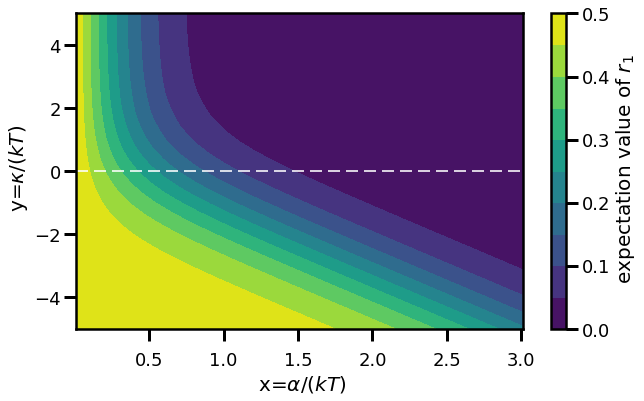

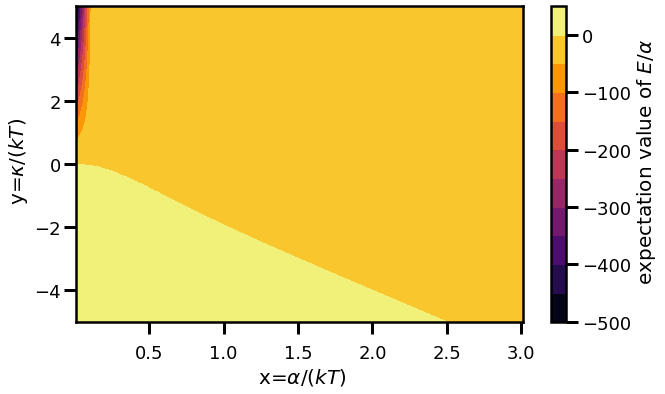

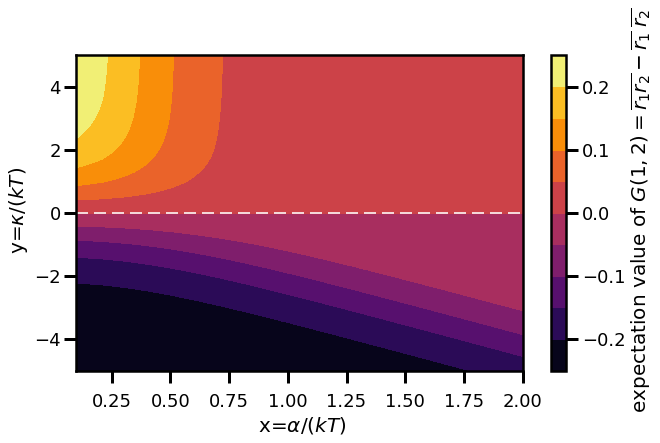

In [ ]:
# The contour plots

# essential things for contour plotting: 
#z = np.sin(xx**2 + yy**2) / (xx**2 + yy**2)
#CS=plt.contourf(x,y,z,10,cmap=plt.cm.bone)
 
# Fig 1: expectation value of the position
fig1=plt.figure(figsize=(10,6))
fig1.subplots_adjust(bottom=0.15) # create space for x-axis label
CS1=plt.contourf(x,y,r1,10,cmap=plt.cm.viridis)
cbar1=plt.colorbar(CS1) # colorbar receives information from contourf
cbar1.ax.set_ylabel(r' expectation value of $r_1$')
plt.xlabel(r' x=$\alpha / (k T )$')
plt.ylabel(r' y=$\kappa / (k T )$')
plt.axhline(y=0.,color='white',dashes=[6,3],alpha=0.8)
fig1.savefig('Reeks5Oef4r1.png')
plt.show(fig1)
print("\n \n")

# Fig 2: expectation value of the energy
fig2=plt.figure(figsize=(10,6))
fig2.subplots_adjust(bottom=0.15) # create space for x-axis label
CS2=plt.contourf(x,y,Energy,10,cmap=plt.cm.inferno)
cbar2=plt.colorbar(CS2) # colorbar receives information from contourf
cbar2.ax.set_ylabel(r' expectation value of $E / \alpha$')
plt.xlabel(r' x=$\alpha / (k T )$')
plt.ylabel(r' y=$\kappa / (k T )$')
fig2.savefig('Reeks5Oef4Energy.png')
plt.show(fig2)
print("\n \n")

# Fig 3: expectation value of the position-position correlation function
fig3=plt.figure(figsize=(10,6))
fig3.subplots_adjust(bottom=0.15) # create space for x-axis label
CS3=plt.contourf(x,y,gr1r2,10,cmap=plt.cm.inferno) #cm.bone for grey tones
cbar3=plt.colorbar(CS3) # colorbar receives information from contourf
cbar3.ax.set_ylabel(r' expectation value of $ G(1,2) = \overline{r_1 r_2} - \overline{r_1} \; \overline{r_2} $')
plt.xlabel(r' x=$\alpha / (k T )$')
plt.ylabel(r' y=$\kappa / (k T )$')
plt.xlim([0.1,2.])
plt.axhline(y=0.,color='white',dashes=[6,3],alpha=0.8)
fig3.savefig('Reeks5Oef4Gr1r2.png')
plt.show(fig3)
print("\n \n")
